In [1]:
import json
import struct
import numpy as np
import matplotlib.pyplot as plt
import photonforge as pf
import siepic_forge as siepic
import luxtelligence_lnoi400_forge as lxt
import tidy3d as td

td.config.logging_level = "ERROR"

# Set up technologies
siepic_tech = siepic.ebeam()
basic_tech = pf.basic_technology()
lxt_tech = lxt.lnoi400()
pf.config.default_technology = siepic_tech

# Initialize live viewer for real-time visualization
from photonforge.live_viewer import LiveViewer
viewer = LiveViewer()

# Define simulation parameters
wavelengths = np.linspace(1.53, 1.57, 101)
freqs = pf.C_0 / wavelengths

LiveViewer started at http://localhost:59957


In [2]:
siepic.component_names

{'ANT_MMI_1x2_te1550_3dB_BB',
 'GC_SiN_TE_1310_8degOxide_BB',
 'GC_SiN_TE_1550_8degOxide_BB',
 'GC_TE_1310_8degOxide_BB',
 'GC_TE_1550_8degOxide_BB',
 'GC_TM_1310_8degOxide_BB',
 'GC_TM_1550_8degOxide_BB',
 'crossing_horizontal',
 'crossing_manhattan',
 'ebeam_BondPad',
 'ebeam_DC_2-1_te895',
 'ebeam_DC_te895',
 'ebeam_MMI_2x2_5050_te1310',
 'ebeam_Polarizer_TM_1550_UQAM',
 'ebeam_YBranch_895',
 'ebeam_YBranch_te1310',
 'ebeam_adiabatic_te1550',
 'ebeam_adiabatic_tm1550',
 'ebeam_bdc_te1550',
 'ebeam_crossing4',
 'ebeam_gc_te1550',
 'ebeam_gc_te895',
 'ebeam_gc_tm1550',
 'ebeam_routing_taper_te1550_w=500nm_to_w=3000nm_L=20um',
 'ebeam_routing_taper_te1550_w=500nm_to_w=3000nm_L=40um',
 'ebeam_splitter_swg_assist_te1310',
 'ebeam_splitter_swg_assist_te1550',
 'ebeam_terminator_SiN_1550',
 'ebeam_terminator_SiN_te895',
 'ebeam_terminator_te1310',
 'ebeam_terminator_te1550',
 'ebeam_terminator_tm1550',
 'ebeam_y_1550',
 'ebeam_y_adiabatic',
 'ebeam_y_adiabatic_500pin',
 'taper_SiN_750_3000

In [5]:
component = siepic.component("ebeam_BondPad")
viewer(component)

In [ ]:
siepic_tech.ports

Name,Classification,Description,Width (μm),Limits (μm),Radius (μm),Modes,Target n_eff,Path profiles (μm),Voltage path,Current path
MM_SiN_TE_1550_3000,optical,"Multimode SiN Strip TE 1550 nm,…… w=3000 nm",8,"-2.5, 2.9",0,7,2.1,'SiN': 3,,
MM_TE_1550_2000,optical,"Multimode Strip TE 1550 nm,…… w=2000 nm",6,"-2, 2.22",0,12,3.5,'Si': 2,,
MM_TE_1550_3000,optical,"Multimode Strip TE 1550 nm,…… w=3000 nm",6,"-2, 2.22",0,17,3.5,'Si': 3,,
Rib_TE_1310_350,optical,"Rib (90 nm slab) TE 1310 nm,…… w=350 nm",2.35,"-1, 1.22",0,1,3.5,"'Si': 0.35, 'Si…… slab': 3",,
Rib_TE_1550_500,optical,"Rib (90 nm slab) TE 1550 nm,…… w=500 nm",2.5,"-1, 1.22",0,1,3.5,"'Si': 0.5, 'Si…… slab': 3",,
SiN_TE-TM_1550_1000,optical,"SiN Strip TM 1550 nm, w=1000 nm",3,"-1.5, 1.9",0,2,2.1,'SiN': 1,,
SiN_TE_1310_750,optical,"SiN Strip TE 1310 nm, w=750 nm",3,"-1, 1.4",0,1,2.1,'SiN': 0.75,,
SiN_TE_1310_800,optical,"SiN Strip TE 1310 nm, w=800 nm",3,"-1, 1.4",0,1,2.1,'SiN': 0.8,,
SiN_TE_1550_1000,optical,"SiN Strip TE 1550 nm, w=1000 nm",3,"-1, 1.4",0,1,2.1,'SiN': 1,,
SiN_TE_1550_750,optical,"SiN Strip TE 1550 nm, w=750 nm",3,"-1, 1.4",0,1,2.1,'SiN': 0.75,,


In [ ]:
lxt_tech.ports

Name,Classification,Description,Width (μm),Limits (μm),Radius (μm),Modes,Target n_eff,Path profiles (μm),Voltage path,Current path
UniCPW,electrical,"CPW (signal width: 15, gap: 5)",188.68,"-97.3477, 101.048",0,1,2.2,"'gnd0'@'TL':…… 250 (-137.5), 'gnd1'@'TL': 250 (+137.5), 'signal'@'TL': 15","(12.5, 1.85) (7.5, 1.85)","(10, 4.8) (-10, 4.8) (-10,…… -1.1) (10, -1.1)"
UniCPW-EO,electrical,"CPW (signal width: 10, gap: 4)",137.784,"-71.0101, 74.7101",0,1,2.2,"'gnd0'@'TL':…… 180 (-99), 'gnd1'@'TL': 180 (+99), 'signal'@'TL': 10","(9, 1.85) (5, 1.85)","(7, 4.3) (-7, 4.3) (-7, -0.6)…… (7, -0.6)"
RWG1000,optical,"LN single mode ridge waveguide…… for C-band, TE mode",5,"-1.5, 1.9",0,2,2.2,"'LN_RIDGE': 1,…… 'LN_SLAB': 10",,
RWG3000,optical,"LN multimode mode ridge for…… C-band, TE mode",8,"-1.5, 1.9",0,5,2.2,"'LN_RIDGE': 3,…… 'LN_SLAB': 12",,
SWG250,optical,"LN strip waveguide for C-band,…… TE mode",10,"-2.1, 2.3",0,1,2.2,"'LN_SLAB': 0.25,…… 'SLAB_NEGATIVE': 12",,


In [ ]:
basic_tech.ports

Name,Classification,Description,Width (μm),Limits (μm),Radius (μm),Modes,Target n_eff,Path profiles (μm),Voltage path,Current path
CPW,electrical,CPW transmission line,26.0552,"-9.05312, 12.9931",0,1 + 1,4,"'gnd0'@……'METAL': 8.9776 (-8.7888), 'gnd1'@'METAL': 8.9776 (+8.7888), 'signal'@'METAL': 3.6","(4.3, 1.97) (1.8, 1.97)","(3.05, 3.47) (-3.05, 3.47)…… (-3.05, 0.47) (3.05, 0.47)"
Rib,optical,Rib waveguide,2.16,"-1, 1.22",0,1,4,"'WG_CORE': 0.4,…… 'SLAB': 2.4, 'WG_CLAD': 2.4",,
Strip,optical,Strip waveguide,2.25,"-1, 1.22",0,1,4,"'WG_CORE': 0.5,…… 'WG_CLAD': 2.5",,


In [7]:
coupler = pf.parametric.dual_ring_coupler(
    port_spec="TE_1550_500", coupling_distance=0.7, coupling_length=16, radius=5, 
    tidy3d_model_kwargs={
        # These symmetries are not correct for arbitrary ports.
        # They can be used in this case for the fundamental mode.
        "port_symmetries": [
            ("P1", "P0", "P3", "P2"),
            ("P2", "P3", "P0", "P1"),
            ("P3", "P2", "P1", "P0"),
        ],
    },
)
viewer(coupler)

In [8]:
pf.tidy3d_plot(coupler, plot_type="3d")

In [18]:
simulations = coupler.active_model.get_simulations(coupler, freqs)

# simulations.keys()
td.web.Batch(simulations=simulations).estimate_cost()

19:23:30 SE Asia Standard Time Maximum FlexCredit cost: 11.537 for the whole    
                               batch.

11.536782863461914

Uploading task 'P0@0…'
Starting task 'P0@0': https://tidy3d.simulation.cloud/workbench?taskId=fdve-4e6008a9-6af8-45b6-a4b3-759f4a80f77d


c:\Users\irfan\AppData\Local\Programs\Python\Python313\Lib\threading.py:994: UserWarning: Task with taskId=fdve-7603e519-55d3-48fe-b70a-37ef7f6bb8da returned status 'aborted'.
  self._target(*self._args, **self._kwargs)


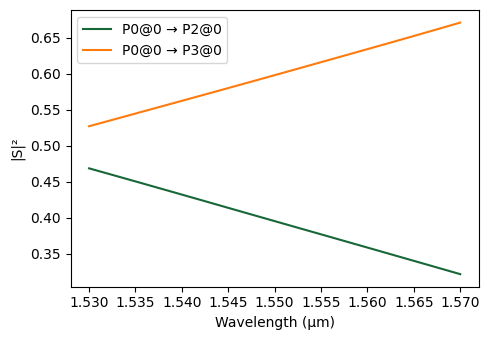

In [15]:
s_matrix = coupler.s_matrix(freqs, model_kwargs={"inputs": ["P0@0"]})
fig, ax = pf.plot_s_matrix(s_matrix, input_ports=["P0"], output_ports=["P2", "P3"])

In [5]:
component = pf.load_layout("gds/Rotator_90.gds")["Main_Rotator"]
viewer(component)

In [ ]:
component = pf.Component("test")

straight = pf.parametric.straight(port_spec="TM_1550_500", length=20)
y_branch = siepic.component("ebeam_y_1550")

str1_ref = component.add_reference(straight)
yb1_ref = component.add_reference(y_branch)

yb1_ref.connect("P0", str1_ref["P1"])

component.add_port(component.detect_ports(["TE_1550_500"], on_boundary="x"))
component.add_model(pf.CircuitModel(), "CircuitModel")


viewer(component)

# s_matrix = y_branch.s_matrix(freqs, model_kwargs={"inputs": ["P0@0"]})
# fig, ax = pf.plot_s_matrix(s_matrix, input_ports=["P0"], output_ports=["P1", "P2"])